In [5]:
import os
import sys
import numpy as np
import torch
import pandas as pd
from PIL import Image
from torch.utils.data import DataLoader

# 固定phase1路径，适配jupyter无__file__
CUR_DIR = r"E:\RETFound\phase1"
sys.path.insert(0, CUR_DIR)

from config import Config
from datasets import REFUGE2Dataset
from models import UNet
from transforms import build_seg_transforms
from engine import evaluate_segmenter
from utils import get_device

# 1. 硬件设备
device = get_device()

# 2. 数据集加载（分割专用transform，尺寸512）
df_all = pd.read_csv(os.path.join(CUR_DIR, "data/data_all.csv"))
val_df = df_all[df_all["split"] == "val"].reset_index(drop=True)
seg_trans = build_seg_transforms(train=False, size=512)
# 分割任务 task="seg"，参数transforms复数
val_ds = REFUGE2Dataset(val_df, transforms=seg_trans, task="seg")
val_loader = DataLoader(val_ds, batch_size=4, shuffle=False)

# 3. 加载UNet最优分割权重
model = UNet(num_classes=3).to(device)
weight_path = r"E:\RETFound\phase1\outputs\baseline_unet_best.pt"
ckpt = torch.load(weight_path, map_location=device)
model.load_state_dict(ckpt["model"])
model.eval()

# 4. 跑验证集，输出视盘/视杯Dice
seg_metrics = evaluate_segmenter(model, val_loader, device)

print("===== 分割验证集指标 =====")
print(f"视盘(Disc) Dice: {seg_metrics['dice_disc']:.4f}")
print(f"视杯(Cup) Dice: {seg_metrics['dice_cup']:.4f}")
print(f"盘杯平均Dice: {seg_metrics['mean_dice']:.4f}")
print(f"vCDR MAE误差: {seg_metrics['vCDR_mae']:.4f}")

C:\Users\len\AppData\Local\Temp\ipykernel_31516\1340603561.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(weight_path, map_location=device)


===== 分割验证集指标 =====
视盘(Disc) Dice: 0.9419
视杯(Cup) Dice: 0.8438
盘杯平均Dice: 0.8929
vCDR MAE误差: 0.0501


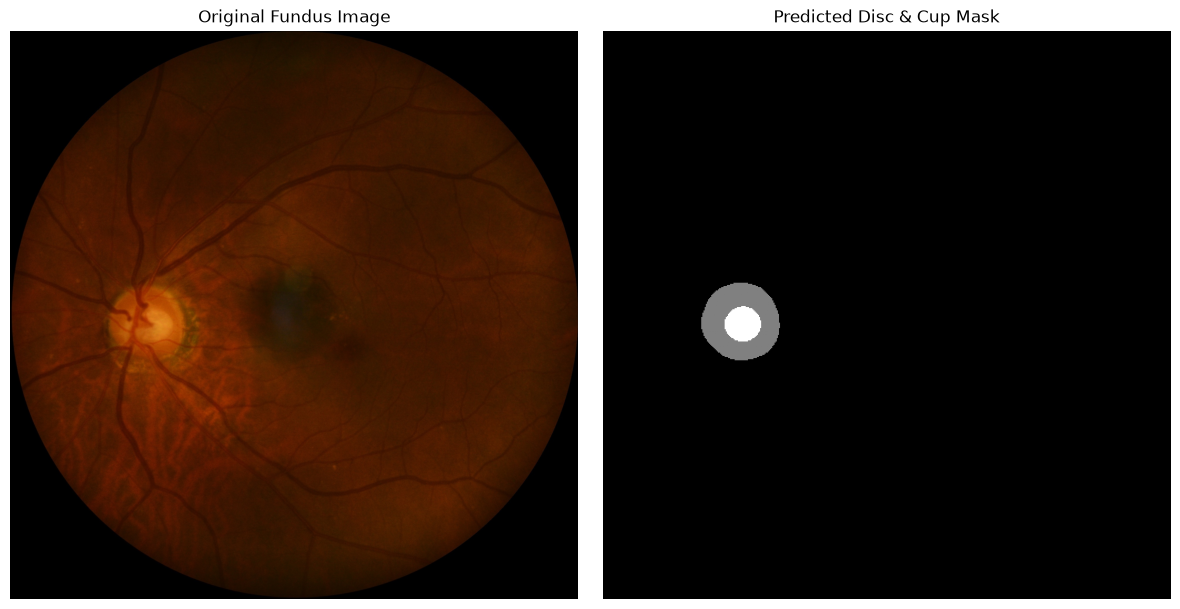

可视化窗口已弹出，无文件保存


In [7]:
import os
import sys
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt

CUR_DIR = r"E:\RETFound\phase1"
sys.path.insert(0, CUR_DIR)

from models import UNet
from transforms import build_seg_transforms
from utils import get_device

device = get_device()
# 1. 加载模型权重，添加weights_only消除警告
model = UNet(num_classes=3).to(device)
weight_path = r"E:\RETFound\phase1\outputs\baseline_unet_best.pt"
ckpt = torch.load(weight_path, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model"])
model.eval()

# 2. 分割预处理（尺寸512）
trans = build_seg_transforms(train=False, size=512)
img_path = r"E:\RETFound\REFUGE2\Val\img\1201.jpg"
img = Image.open(img_path).convert("RGB")
img_np = np.array(img)  # albumentations必须输入numpy数组

# 3. 前向推理
aug_out = trans(image=img_np)
img_tensor = aug_out["image"].unsqueeze(0).to(device)
with torch.no_grad():
    pred_logit = model(img_tensor)
pred_mask = torch.argmax(pred_logit, dim=1).squeeze().cpu().numpy()

# 4. 映射掩码像素值（匹配数据集标准：0=杯，1=盘，2=背景）
mask_vis = np.zeros_like(pred_mask, dtype=np.uint8)
mask_vis[pred_mask == 0] = 0      # 视杯 黑色
mask_vis[pred_mask == 1] = 128    # 视盘 灰色
mask_vis[pred_mask == 2] = 255    # 背景 白色

# 5. 可视化原图 + 分割掩码（不再保存文件）
plt.figure(figsize=(12, 6))

# 原图
plt.subplot(1, 2, 1)
plt.imshow(img_np)
plt.title("Original Fundus Image")
plt.axis("off")

# 预测分割掩码
plt.subplot(1, 2, 2)
plt.imshow(mask_vis, cmap="gray")
plt.title("Predicted Disc & Cup Mask")
plt.axis("off")

plt.tight_layout()
plt.show()
print("可视化窗口已弹出，无文件保存")

In [9]:
import os
import sys
import numpy as np
import torch
import pandas as pd
from PIL import Image
from torch.utils.data import DataLoader

# 固定phase1路径，适配jupyter无__file__
CUR_DIR = r"E:\RETFound\phase1"
sys.path.insert(0, CUR_DIR)

from config import Config
from datasets import REFUGE2Dataset
from models import UNet
from transforms import build_seg_transforms
from engine import evaluate_segmenter
from utils import get_device

# 1. 硬件设备
device = get_device()

# 2. 数据集加载（分割专用transform，尺寸512）
df_all = pd.read_csv(os.path.join(CUR_DIR, "data/data_all.csv"))
val_df = df_all[df_all["split"] == "test"].reset_index(drop=True)
seg_trans = build_seg_transforms(train=False, size=512)
# 分割任务 task="seg"，参数transforms复数
val_ds = REFUGE2Dataset(val_df, transforms=seg_trans, task="seg")
val_loader = DataLoader(val_ds, batch_size=4, shuffle=False)

# 3. 加载UNet最优分割权重
model = UNet(num_classes=3).to(device)
weight_path = r"E:\RETFound\phase1\outputs\baseline_unet_best.pt"
ckpt = torch.load(weight_path, map_location=device)
model.load_state_dict(ckpt["model"])
model.eval()

# 4. 跑验证集，输出视盘/视杯Dice
seg_metrics = evaluate_segmenter(model, val_loader, device)

print("===== 分割验证集指标 =====")
print(f"视盘(Disc) Dice: {seg_metrics['dice_disc']:.4f}")
print(f"视杯(Cup) Dice: {seg_metrics['dice_cup']:.4f}")
print(f"盘杯平均Dice: {seg_metrics['mean_dice']:.4f}")
print(f"vCDR MAE误差: {seg_metrics['vCDR_mae']:.4f}")

C:\Users\len\AppData\Local\Temp\ipykernel_31516\4010617681.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(weight_path, map_location=device)


===== 分割验证集指标 =====
视盘(Disc) Dice: 0.9287
视杯(Cup) Dice: 0.8448
盘杯平均Dice: 0.8867
vCDR MAE误差: 0.0684


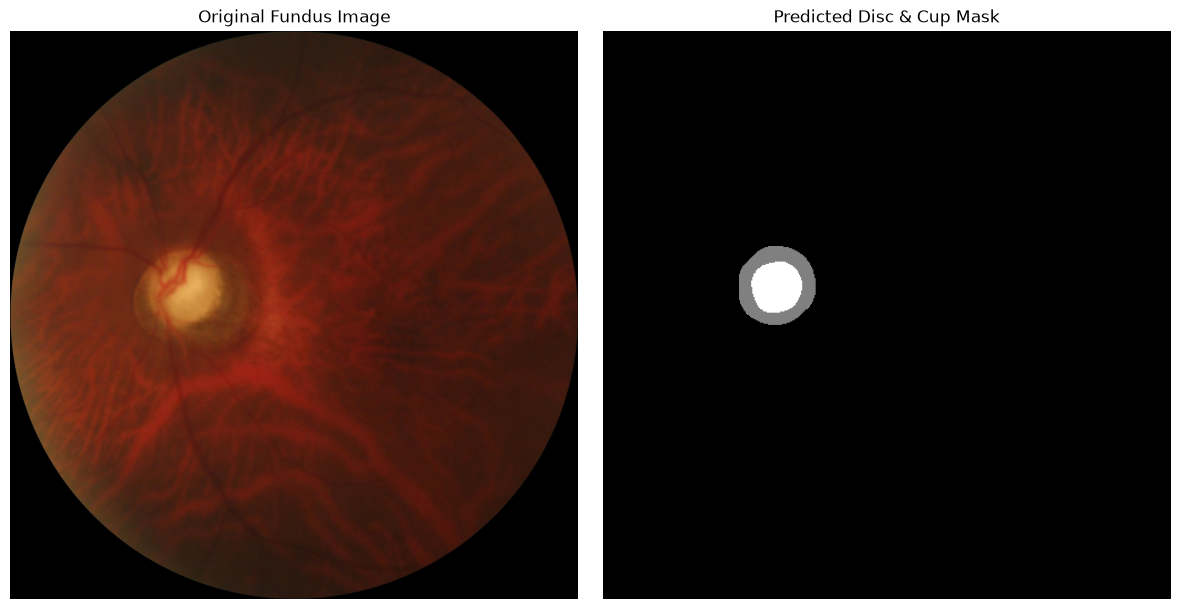

可视化窗口已弹出，无文件保存


In [8]:
import os
import sys
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt

CUR_DIR = r"E:\RETFound\phase1"
sys.path.insert(0, CUR_DIR)

from models import UNet
from transforms import build_seg_transforms
from utils import get_device

device = get_device()
# 1. 加载模型权重，添加weights_only消除警告
model = UNet(num_classes=3).to(device)
weight_path = r"E:\RETFound\phase1\outputs\baseline_unet_best.pt"
ckpt = torch.load(weight_path, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model"])
model.eval()

# 2. 分割预处理（尺寸512）
trans = build_seg_transforms(train=False, size=512)
img_path = r"E:\RETFound\REFUGE2\Test\img\1601.jpg"
img = Image.open(img_path).convert("RGB")
img_np = np.array(img)  # albumentations必须输入numpy数组

# 3. 前向推理
aug_out = trans(image=img_np)
img_tensor = aug_out["image"].unsqueeze(0).to(device)
with torch.no_grad():
    pred_logit = model(img_tensor)
pred_mask = torch.argmax(pred_logit, dim=1).squeeze().cpu().numpy()

# 4. 映射掩码像素值（匹配数据集标准：0=杯，1=盘，2=背景）
mask_vis = np.zeros_like(pred_mask, dtype=np.uint8)
mask_vis[pred_mask == 0] = 0      # 视杯 黑色
mask_vis[pred_mask == 1] = 128    # 视盘 灰色
mask_vis[pred_mask == 2] = 255    # 背景 白色

# 5. 可视化原图 + 分割掩码（不再保存文件）
plt.figure(figsize=(12, 6))

# 原图
plt.subplot(1, 2, 1)
plt.imshow(img_np)
plt.title("Original Fundus Image")
plt.axis("off")

# 预测分割掩码
plt.subplot(1, 2, 2)
plt.imshow(mask_vis, cmap="gray")
plt.title("Predicted Disc & Cup Mask")
plt.axis("off")

plt.tight_layout()
plt.show()
print("可视化窗口已弹出，无文件保存")